In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load data
train_df = pd.read_csv('fashion-mnist_train.csv')
test_df  = pd.read_csv('fashion-mnist_test.csv')

print(f"Train shape: {train_df.shape}")   # (60000, 785)
print(f"Test shape : {test_df.shape}")    # (10000, 785)

# Tách label và features
X_train = train_df.iloc[:, 1:].values     # (60000, 784)
y_train = train_df.iloc[:, 0].values      # (60000,)

X_test  = test_df.iloc[:, 1:].values
y_test  = test_df.iloc[:, 0].values

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")

Train shape: (60000, 785)
Test shape : (10000, 785)
X_train shape: (60000, 784), y_train shape: (60000,)


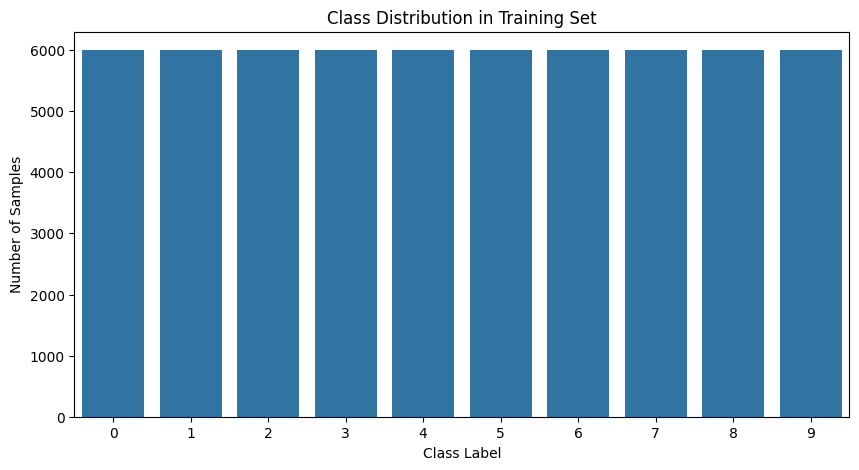

{np.int64(0): np.int64(6000), np.int64(1): np.int64(6000), np.int64(2): np.int64(6000), np.int64(3): np.int64(6000), np.int64(4): np.int64(6000), np.int64(5): np.int64(6000), np.int64(6): np.int64(6000), np.int64(7): np.int64(6000), np.int64(8): np.int64(6000), np.int64(9): np.int64(6000)}


In [2]:
import seaborn as sns

# Class distribution in train set
plt.figure(figsize=(10, 5))
sns.countplot(x=y_train)
plt.title('Class Distribution in Training Set')
plt.xlabel('Class Label')
plt.ylabel('Number of Samples')
plt.show()

# Kiểm tra số lượng từng lớp
unique, counts = np.unique(y_train, return_counts=True)
print(dict(zip(unique, counts)))   # Nên ra 6000 cho mỗi lớp

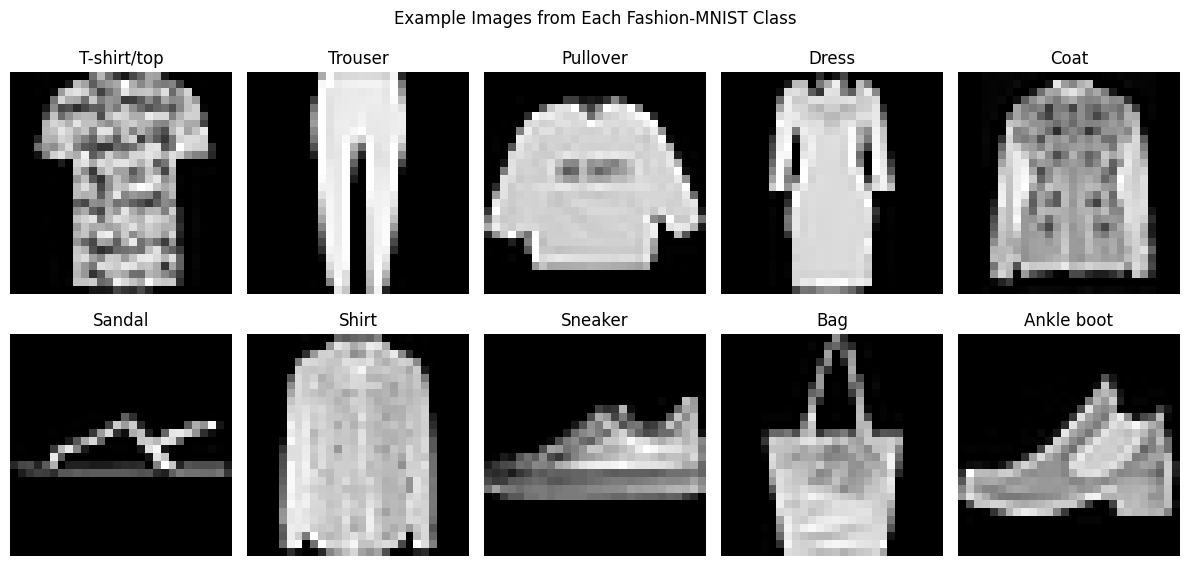

In [3]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Hiển thị 10 ảnh đại diện (một ảnh cho mỗi lớp)
plt.figure(figsize=(12, 6))
for i in range(10):
    # Tìm index đầu tiên của lớp i
    idx = np.where(y_train == i)[0][0]
    plt.subplot(2, 5, i+1)
    plt.imshow(X_train[idx].reshape(28, 28), cmap='gray')
    plt.title(class_names[i])
    plt.axis('off')
plt.suptitle('Example Images from Each Fashion-MNIST Class')
plt.tight_layout()
plt.show()

In [ ]:
X_train_raw = train_df.iloc[:, 1:].values.astype('float32')
y_train_raw = train_df.iloc[:, 0].values
X_test_raw  = test_df.iloc[:, 1:].values.astype('float32')
y_test      = test_df.iloc[:, 0].values

print(f"Original train shape: {X_train_raw.shape}, Test shape: {X_test_raw.shape}")

Original train shape: (60000, 784), Test shape: (10000, 784)


In [5]:

# ====================== 2.2 Train - Validation Split ======================
# Tách 20% từ train set để làm validation (giữ stratified để cân bằng lớp)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_raw, y_train_raw, test_size=0.2, random_state=42, stratify=y_train_raw
)

print(f"Final shapes:")
print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_val  : {X_val.shape},   y_val  : {y_val.shape}")
print(f"X_test : {X_test_raw.shape}, y_test : {y_test.shape}")

Final shapes:
X_train: (48000, 784), y_train: (48000,)
X_val  : (12000, 784),   y_val  : (12000,)
X_test : (10000, 784), y_test : (10000,)


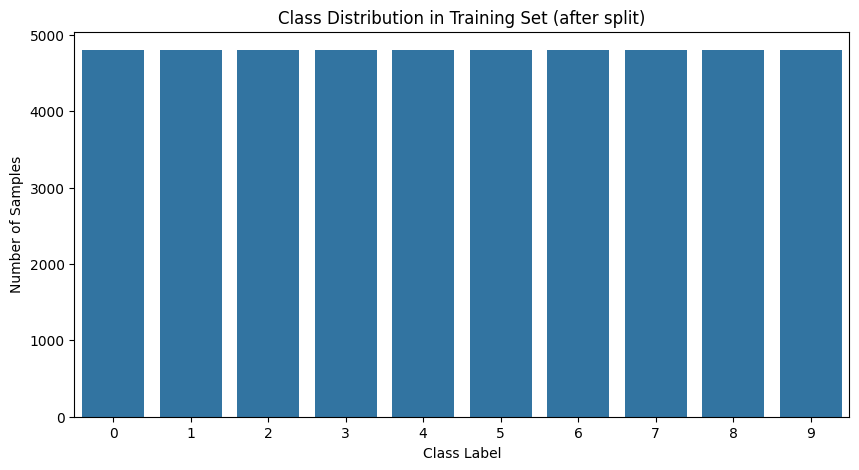

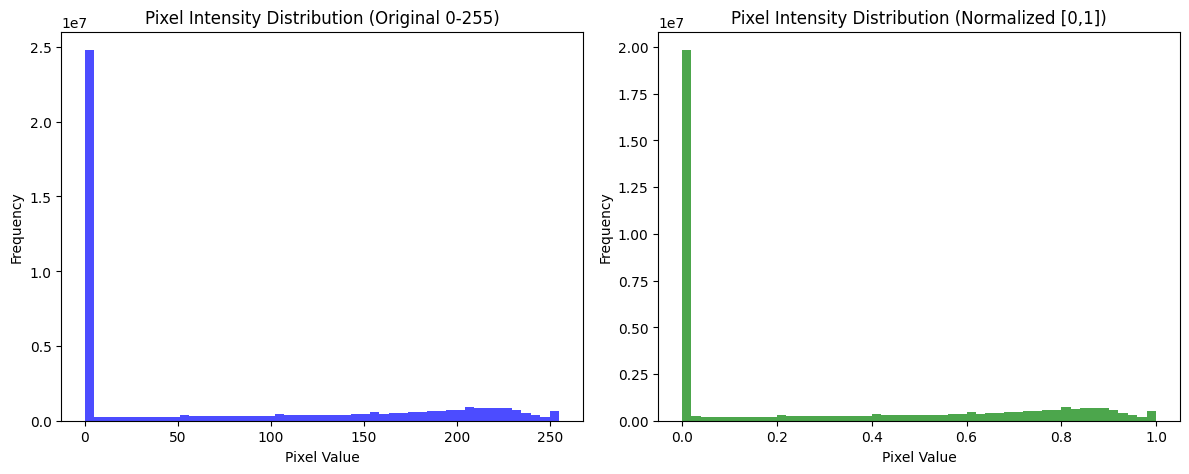

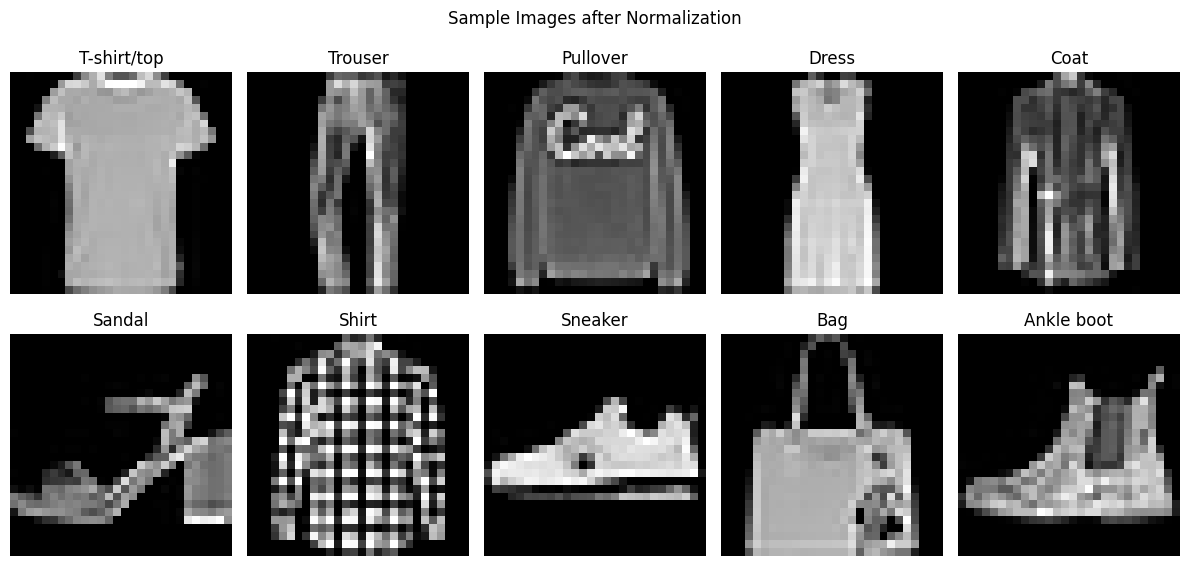

In [ ]:
# ====================== 2.3 Normalization ======================
# Pixel normalization: đưa về khoảng [0, 1]
X_train_norm = X_train / 255.0
X_val_norm   = X_val / 255.0
X_test_norm  = X_test_raw / 255.0

# ====================== 2.4 Exploratory Data Analysis & Visualization ======================

# 1. Class distribution
plt.figure(figsize=(10, 5))
sns.countplot(x=y_train)
plt.title('Class Distribution in Training Set (after split)')
plt.xlabel('Class Label')
plt.ylabel('Number of Samples')
#plt.savefig('figures/class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

# 2. Pixel intensity distribution (before & after normalization)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(X_train_raw.ravel(), bins=50, color='blue', alpha=0.7)
plt.title('Pixel Intensity Distribution (Original 0-255)')
plt.xlabel('Pixel Value')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
plt.hist(X_train_norm.ravel(), bins=50, color='green', alpha=0.7)
plt.title('Pixel Intensity Distribution (Normalized [0,1])')
plt.xlabel('Pixel Value')
plt.ylabel('Frequency')
plt.tight_layout()
#plt.savefig('figures/pixel_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

# 3. Sample images after preprocessing (để kiểm tra)
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

plt.figure(figsize=(12, 6))
for i in range(10):
    idx = np.where(y_train == i)[0][0]
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train_norm[idx].reshape(28, 28), cmap='gray')
    plt.title(class_names[i])
    plt.axis('off')
plt.suptitle('Sample Images after Normalization')
plt.tight_layout()
#plt.savefig('figures/samples_after_norm.png', dpi=300, bbox_inches='tight')
plt.show()